Part A (Numpy)

Epoch [1/10] Train Loss: 0.5545 Val Loss: 0.4363 Train Acc: 79.80% Val Acc: 84.62%
Epoch [2/10] Train Loss: 0.4046 Val Loss: 0.4018 Train Acc: 85.39% Val Acc: 85.14%
Epoch [3/10] Train Loss: 0.3554 Val Loss: 0.3936 Train Acc: 86.99% Val Acc: 86.12%
Epoch [4/10] Train Loss: 0.3283 Val Loss: 0.3465 Train Acc: 87.79% Val Acc: 87.55%
Epoch [5/10] Train Loss: 0.3081 Val Loss: 0.3660 Train Acc: 88.74% Val Acc: 87.14%
Epoch [6/10] Train Loss: 0.2862 Val Loss: 0.3407 Train Acc: 89.44% Val Acc: 87.83%
Epoch [7/10] Train Loss: 0.2700 Val Loss: 0.3251 Train Acc: 89.99% Val Acc: 88.34%
Epoch [8/10] Train Loss: 0.2557 Val Loss: 0.3401 Train Acc: 90.45% Val Acc: 88.62%
Epoch [9/10] Train Loss: 0.2440 Val Loss: 0.3199 Train Acc: 90.87% Val Acc: 89.17%
Epoch [10/10] Train Loss: 0.2321 Val Loss: 0.3168 Train Acc: 91.33% Val Acc: 89.10%


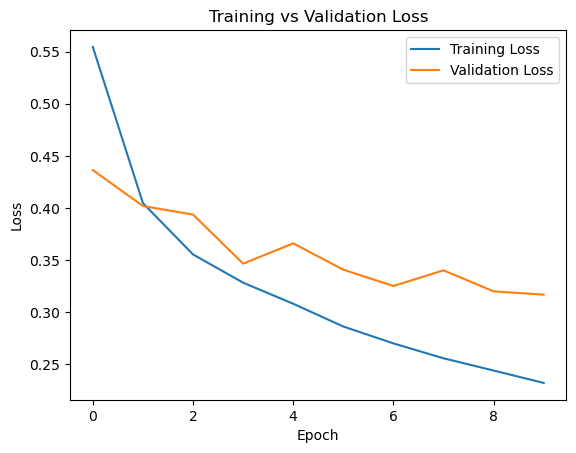

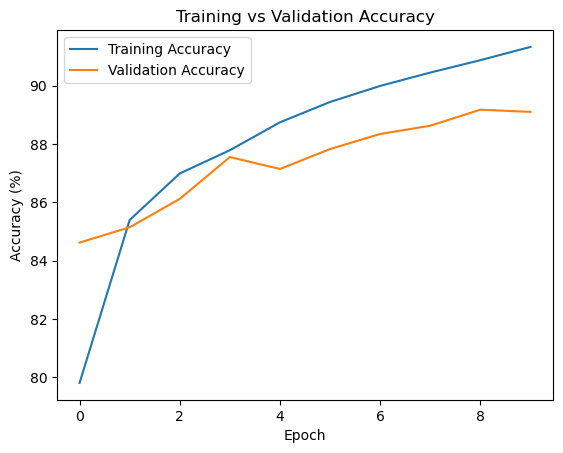

In [2]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
from torch.utils.data import DataLoader, random_split
import matplotlib.pyplot as plt

# ----------------------------
# Device
# ----------------------------
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# ----------------------------
# Load Fashion MNIST
# ----------------------------
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])

dataset = torchvision.datasets.FashionMNIST(
    root='./data',
    train=True,
    download=True,
    transform=transform
)

train_size = int(0.8 * len(dataset))
val_size = len(dataset) - train_size
train_dataset, val_dataset = random_split(dataset, [train_size, val_size])

train_loader = DataLoader(train_dataset, batch_size=128, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=128, shuffle=False)

# ----------------------------
# Large Over-Parameterized Model
# ----------------------------
class LargeMLP(nn.Module):
    def __init__(self):
        super(LargeMLP, self).__init__()
        self.model = nn.Sequential(
            nn.Flatten(),
            nn.Linear(28*28, 2048),
            nn.ReLU(),
            nn.Linear(2048, 2048),
            nn.ReLU(),
            nn.Linear(2048, 1024),
            nn.ReLU(),
            nn.Linear(1024, 512),
            nn.ReLU(),
            nn.Linear(512, 10)
        )

    def forward(self, x):
        return self.model(x)

model = LargeMLP().to(device)

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

# ----------------------------
# Training Loop
# ----------------------------
num_epochs = 10

train_losses = []
val_losses = []
train_accuracies = []
val_accuracies = []

for epoch in range(num_epochs):

    # Training
    model.train()
    running_train_loss = 0.0
    correct_train = 0
    total_train = 0

    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_train_loss += loss.item()

        _, predicted = torch.max(outputs, 1)
        total_train += labels.size(0)
        correct_train += (predicted == labels).sum().item()

    avg_train_loss = running_train_loss / len(train_loader)
    train_accuracy = 100 * correct_train / total_train

    train_losses.append(avg_train_loss)
    train_accuracies.append(train_accuracy)

    # Validation
    model.eval()
    running_val_loss = 0.0
    correct_val = 0
    total_val = 0

    with torch.no_grad():
        for images, labels in val_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            loss = criterion(outputs, labels)

            running_val_loss += loss.item()

            _, predicted = torch.max(outputs, 1)
            total_val += labels.size(0)
            correct_val += (predicted == labels).sum().item()

    avg_val_loss = running_val_loss / len(val_loader)
    val_accuracy = 100 * correct_val / total_val

    val_losses.append(avg_val_loss)
    val_accuracies.append(val_accuracy)

    print(f"Epoch [{epoch+1}/{num_epochs}] "
          f"Train Loss: {avg_train_loss:.4f} "
          f"Val Loss: {avg_val_loss:.4f} "
          f"Train Acc: {train_accuracy:.2f}% "
          f"Val Acc: {val_accuracy:.2f}%")

# ----------------------------
# Plot Loss Curves
# ----------------------------
plt.figure()
plt.plot(train_losses, label="Training Loss")
plt.plot(val_losses, label="Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.title("Training vs Validation Loss")
plt.show()

# ----------------------------
# Plot Accuracy Curves
# ----------------------------
plt.figure()
plt.plot(train_accuracies, label="Training Accuracy")
plt.plot(val_accuracies, label="Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy (%)")
plt.legend()
plt.title("Training vs Validation Accuracy")
plt.show()

Part B (Keras)

c:\Users\quinc\miniconda3\envs\myenv\Lib\site-packages\keras\src\layers\core\dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/120
129/129 ━━━━━━━━━━━━━━━━━━━━ 6s 24ms/step - loss: 0.7418 - val_loss: 0.3940
Epoch 2/120
129/129 ━━━━━━━━━━━━━━━━━━━━ 3s 21ms/step - loss: 0.3808 - val_loss: 0.3551
Epoch 3/120
129/129 ━━━━━━━━━━━━━━━━━━━━ 3s 20ms/step - loss: 0.3577 - val_loss: 0.3399
Epoch 4/120
129/129 ━━━━━━━━━━━━━━━━━━━━ 5s 21ms/step - loss: 0.3385 - val_loss: 0.3228
Epoch 5/120
129/129 ━━━━━━━━━━━━━━━━━━━━ 5s 23ms/step - loss: 0.3227 - val_loss: 0.3132
Epoch 6/120
129/129 ━━━━━━━━━━━━━━━━━━━━ 3s 20ms/step - loss: 0.3053 - val_loss: 0.3023
Epoch 7/120
129/129 ━━━━━━━━━━━━━━━━━━━━ 3s 21ms/step - loss: 0.2979 - val_loss: 0.2963
Epoch 8/120
129/129 ━━━━━━━━━━━━━━━━━━━━ 3s 21ms/step - loss: 0.2909 - val_loss: 0.2904
Epoch 9/120
129/129 ━━━━━━━━━━━━━━━━━━━━ 3s 21ms/step - loss: 0.2868 - val_loss: 0.2899
Epoch 10/120
129/129 ━━━━━━━━━━━━━━━━━━━━ 3s 21ms/step - loss: 0.2822 - val_loss: 0.2852
Epoch 11/120
129/129 ━━━━━━━━━━━━━━━━━━━━ 3s 21ms/step - loss: 0.2766 - val_loss: 0.2857
Epoch 12/120
129/129 ━━━━━━━━━

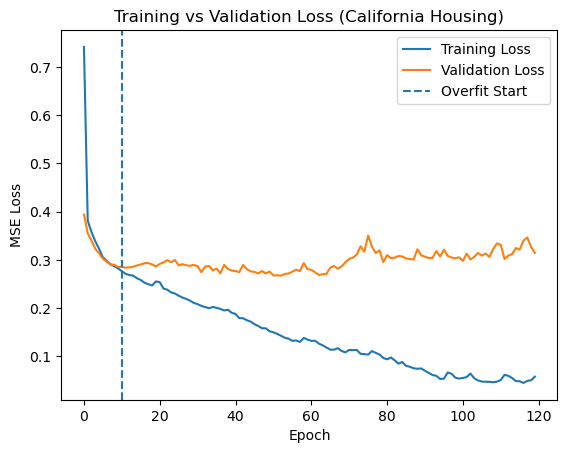

In [4]:
# --------------------------------------------------------
# California Housing - Intentional Overfitting (Keras)
# --------------------------------------------------------

import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf

from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

# --------------------------------------------------------
# 1. Reproducibility
# --------------------------------------------------------

np.random.seed(42)
tf.random.set_seed(42)

# --------------------------------------------------------
# 2. Load Dataset
# --------------------------------------------------------

housing = fetch_california_housing()
X = housing.data
y = housing.target  # Continuous target (median house value)

# --------------------------------------------------------
# 3. Train / Validation Split
# --------------------------------------------------------

X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# --------------------------------------------------------
# 4. Standardize Features (mean=0, std=1)
# IMPORTANT: Fit only on training data
# --------------------------------------------------------

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_val = scaler.transform(X_val)

# --------------------------------------------------------
# 5. Build Large Over-Parameterized Model
# No dropout, no L1/L2 regularization
# --------------------------------------------------------

model = Sequential([
    Dense(1024, activation='relu', input_shape=(X_train.shape[1],)),
    Dense(1024, activation='relu'),
    Dense(512, activation='relu'),
    Dense(512, activation='relu'),
    Dense(256, activation='relu'),
    Dense(128, activation='relu'),
    Dense(1)  # Regression output
])

# --------------------------------------------------------
# 6. Compile Model
# Using MSE for regression
# --------------------------------------------------------

model.compile(
    optimizer='adam',
    loss='mse'
)

# --------------------------------------------------------
# 7. Train Model (100+ epochs)
# --------------------------------------------------------

history = model.fit(
    X_train,
    y_train,
    validation_data=(X_val, y_val),
    epochs=120,
    batch_size=128,
    verbose=1
)

# --------------------------------------------------------
# 8. Extract Loss Values
# --------------------------------------------------------

train_losses = history.history['loss']
val_losses = history.history['val_loss']

# --------------------------------------------------------
# 9. Identify Overfitting Epoch
# Overfitting starts when validation loss increases
# while training loss decreases
# --------------------------------------------------------

overfit_epoch = None
for i in range(1, len(val_losses)):
    if val_losses[i] > val_losses[i-1] and train_losses[i] < train_losses[i-1]:
        overfit_epoch = i + 1
        break

if overfit_epoch:
    print(f"\nOverfitting begins around epoch: {overfit_epoch}")
else:
    print("\nOverfitting point not clearly detected. Consider increasing model size.")

# --------------------------------------------------------
# 10. Plot Training vs Validation Loss
# --------------------------------------------------------

plt.figure()
plt.plot(train_losses, label="Training Loss")
plt.plot(val_losses, label="Validation Loss")

if overfit_epoch:
    plt.axvline(x=overfit_epoch-1, linestyle='--', label="Overfit Start")

plt.xlabel("Epoch")
plt.ylabel("MSE Loss")
plt.title("Training vs Validation Loss (California Housing)")
plt.legend()
plt.show()